In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("malaria_ssa_baseline_1000.csv")

df.head()

,patient_id,age_years,age_months,age_group,sex,residence,season,uses_mosquito_net,malaria_status,parasitemia_level,...,has_vomiting,has_diarrhea,has_weakness,severe_malaria,cerebral_malaria,respiratory_distress,shock,acute_kidney_injury,outcome,malaria_probability_score
0,MAL000001,6,76.0,6-12,Male,Rural,Dry,False,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.437
1,MAL000002,0,10.0,0-2,Male,Rural,Dry,False,Positive,Moderate,...,False,False,True,False,False,False,False,False,Treated,0.546
2,MAL000003,17,210.0,12+,Female,Rural,Dry,True,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.182
3,MAL000004,4,52.0,2-6,Female,Rural,Rainy,True,Positive,High,...,True,True,False,False,False,False,False,False,Treated,0.546
4,MAL000005,2,34.0,2-6,Female,Rural,Rainy,True,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.546


In [ ]:
df.shape

(1000, 28)

In [ ]:
df.columns.tolist()

['patient_id',
 'age_years',
 'age_months',
 'age_group',
 'sex',
 'residence',
 'season',
 'uses_mosquito_net',
 'malaria_status',
 'parasitemia_level',
 'parasitemia_count',
 'plasmodium_species',
 'hemoglobin_g_dl',
 'anemia_status',
 'fever_days',
 'has_fever',
 'has_chills',
 'has_headache',
 'has_vomiting',
 'has_diarrhea',
 'has_weakness',
 'severe_malaria',
 'cerebral_malaria',
 'respiratory_distress',
 'shock',
 'acute_kidney_injury',
 'outcome',
 'malaria_probability_score']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 1000 non-null   object 
 1   age_years                  1000 non-null   int64  
 2   age_months                 1000 non-null   float64
 3   age_group                  1000 non-null   object 
 4   sex                        1000 non-null   object 
 5   residence                  1000 non-null   object 
 6   season                     1000 non-null   object 
 7   uses_mosquito_net          1000 non-null   bool   
 8   malaria_status             1000 non-null   object 
 9   parasitemia_level          531 non-null    object 
 10  parasitemia_count          1000 non-null   int64  
 11  plasmodium_species         531 non-null    object 
 12  hemoglobin_g_dl            1000 non-null   float64
 13  anemia_status              210 non-null    object

In [ ]:
df.isnull().sum()

,0
patient_id,0
age_years,0
age_months,0
age_group,0
sex,0
residence,0
season,0
uses_mosquito_net,0
malaria_status,0
parasitemia_level,469


In [ ]:
df["malaria_status"].value_counts()

,count
malaria_status,
Positive,531
Negative,469


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["patient_id"].duplicated().sum()

np.int64(0)

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
anemia_status,790
parasitemia_level,469
plasmodium_species,469


In [ ]:
selected_columns = [
    "age_years",
    "sex",
    "residence",
    "season",
    "uses_mosquito_net",
    "fever_days",
    "has_fever",
    "has_chills",
    "has_headache",
    "has_vomiting",
    "has_diarrhea",
    "has_weakness",
    "malaria_status"
]

df[selected_columns].head()

,age_years,sex,residence,season,uses_mosquito_net,fever_days,has_fever,has_chills,has_headache,has_vomiting,has_diarrhea,has_weakness,malaria_status
0,6,Male,Rural,Dry,False,0,False,False,False,False,False,False,Negative
1,0,Male,Rural,Dry,False,3,True,True,False,False,False,True,Positive
2,17,Female,Rural,Dry,True,0,False,False,False,False,False,False,Negative
3,4,Female,Rural,Rainy,True,4,True,True,True,True,True,False,Positive
4,2,Female,Rural,Rainy,True,0,False,False,False,False,False,False,Negative


In [ ]:
pd.crosstab(
    df["malaria_status"],
    df["has_fever"]
)

has_fever,False,True
malaria_status,,
Negative,469,0
Positive,32,499


In [ ]:
pd.crosstab(
    df["malaria_status"],
    df["has_chills"]
)

has_chills,False,True
malaria_status,,
Negative,469,0
Positive,87,444


In [ ]:
pd.crosstab(
    df["malaria_status"],
    df["has_headache"]
)

has_headache,False,True
malaria_status,,
Negative,469,0
Positive,179,352


In [ ]:
model_df = df[selected_columns].copy()

model_df.head()

,age_years,sex,residence,season,uses_mosquito_net,fever_days,has_fever,has_chills,has_headache,has_vomiting,has_diarrhea,has_weakness,malaria_status
0,6,Male,Rural,Dry,False,0,False,False,False,False,False,False,Negative
1,0,Male,Rural,Dry,False,3,True,True,False,False,False,True,Positive
2,17,Female,Rural,Dry,True,0,False,False,False,False,False,False,Negative
3,4,Female,Rural,Rainy,True,4,True,True,True,True,True,False,Positive
4,2,Female,Rural,Rainy,True,0,False,False,False,False,False,False,Negative


In [ ]:
model_df.shape

(1000, 13)

In [ ]:
symptom_columns = [
    "has_fever",
    "has_chills",
    "has_headache",
    "has_vomiting",
    "has_diarrhea",
    "has_weakness"
]

symptom_summary = (
    model_df
    .groupby("malaria_status")[symptom_columns]
    .mean()
    .T * 100
)

symptom_summary

malaria_status,Negative,Positive
has_fever,0.0,93.973635
has_chills,0.0,83.615819
has_headache,0.0,66.290019
has_vomiting,0.0,48.022599
has_diarrhea,0.0,27.871940
has_weakness,0.0,85.122411


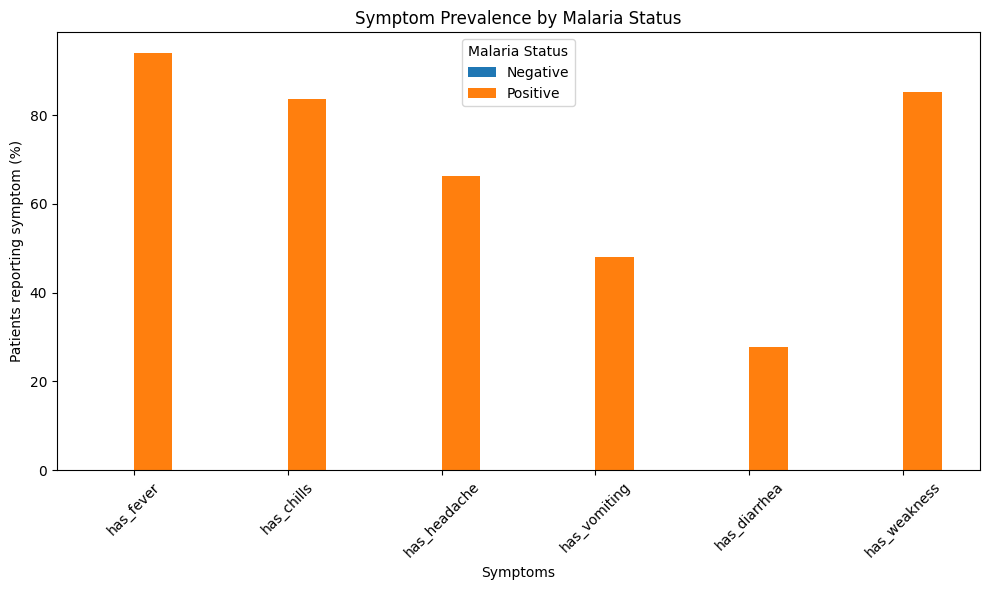

In [ ]:
symptom_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Symptom Prevalence by Malaria Status")
plt.xlabel("Symptoms")
plt.ylabel("Patients reporting symptom (%)")
plt.xticks(rotation=45)
plt.legend(title="Malaria Status")
plt.tight_layout()
plt.show()

In [ ]:
X = model_df.drop("malaria_status", axis=1)

y = model_df["malaria_status"]

In [ ]:
X.head()

,age_years,sex,residence,season,uses_mosquito_net,fever_days,has_fever,has_chills,has_headache,has_vomiting,has_diarrhea,has_weakness
0,6,Male,Rural,Dry,False,0,False,False,False,False,False,False
1,0,Male,Rural,Dry,False,3,True,True,False,False,False,True
2,17,Female,Rural,Dry,True,0,False,False,False,False,False,False
3,4,Female,Rural,Rainy,True,4,True,True,True,True,True,False
4,2,Female,Rural,Rainy,True,0,False,False,False,False,False,False


In [ ]:
y.head()

,malaria_status
0,Negative
1,Positive
2,Negative
3,Positive
4,Negative


In [ ]:
y = y.map({
    "Negative": 0,
    "Positive": 1
})

In [ ]:
y.value_counts()

,count
malaria_status,
1,531
0,469


In [ ]:
for column in ["sex", "residence", "season"]:
    print(column)
    print(X[column].value_counts())
    print()

sex
sex
Male      600
Female    400
Name: count, dtype: int64

residence
residence
Rural    856
Urban    144
Name: count, dtype: int64

season
season
Rainy    613
Dry      387
Name: count, dtype: int64



In [ ]:
categorical_features = [
    "sex",
    "residence",
    "season"
]

numeric_features = [
    "age_years",
    "fever_days"
]

binary_features = [
    "uses_mosquito_net",
    "has_fever",
    "has_chills",
    "has_headache",
    "has_vomiting",
    "has_diarrhea",
    "has_weakness"
]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)
print("Binary:", binary_features)

Categorical: ['sex', 'residence', 'season']
Numeric: ['age_years', 'fever_days']
Binary: ['uses_mosquito_net', 'has_fever', 'has_chills', 'has_headache', 'has_vomiting', 'has_diarrhea', 'has_weakness']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (800, 12)
Testing features: (200, 12)
Training target: (800,)
Testing target: (200,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_logistic[:20]

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        94
    Positive       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

cm

array([[ 94,   0],
       [  0, 106]])

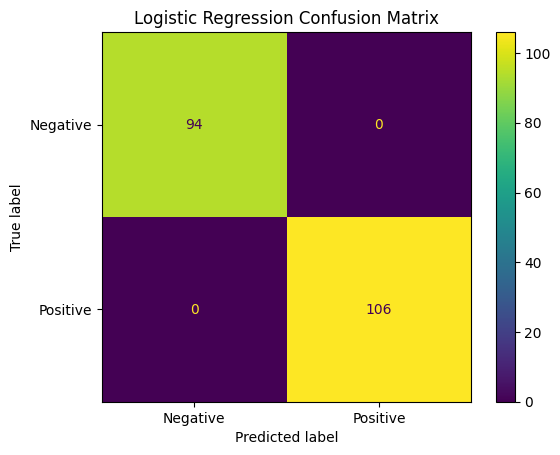

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Negative", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        94
    Positive       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

In [ ]:
y_pred_rf[:20]

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 100.0 %


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        94
    Positive       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



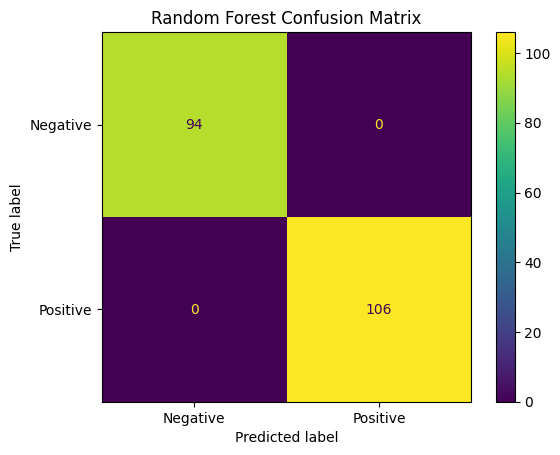

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Negative", "Positive"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


In [ ]:
comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,1.0,100.0
1,Random Forest,1.0,100.0


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
logistic_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

print("Logistic Regression")

print(
    "Average Accuracy:",
    round(logistic_cv["test_accuracy"].mean() * 100, 2),
    "%"
)

print(
    "Average Precision:",
    round(logistic_cv["test_precision"].mean() * 100, 2),
    "%"
)

print(
    "Average Recall:",
    round(logistic_cv["test_recall"].mean() * 100, 2),
    "%"
)

print(
    "Average F1 Score:",
    round(logistic_cv["test_f1"].mean() * 100, 2),
    "%"
)

Logistic Regression
Average Accuracy: 99.9 %
Average Precision: 100.0 %
Average Recall: 99.81 %
Average F1 Score: 99.91 %


In [ ]:
logistic_cv["test_accuracy"] * 100

array([100. , 100. ,  99.5, 100. , 100. ])

In [ ]:
rf_cv = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

print("Random Forest")

print(
    "Average Accuracy:",
    round(rf_cv["test_accuracy"].mean() * 100, 2),
    "%"
)

print(
    "Average Precision:",
    round(rf_cv["test_precision"].mean() * 100, 2),
    "%"
)

print(
    "Average Recall:",
    round(rf_cv["test_recall"].mean() * 100, 2),
    "%"
)

print(
    "Average F1 Score:",
    round(rf_cv["test_f1"].mean() * 100, 2),
    "%"
)

Random Forest
Average Accuracy: 100.0 %
Average Precision: 100.0 %
Average Recall: 100.0 %
Average F1 Score: 100.0 %


In [ ]:
rf_cv["test_accuracy"] * 100

array([100., 100., 100., 100., 100.])

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test Accuracy (%)": [
        logistic_accuracy * 100,
        rf_accuracy * 100
    ],
    "CV Accuracy (%)": [
        logistic_cv["test_accuracy"].mean() * 100,
        rf_cv["test_accuracy"].mean() * 100
    ],
    "CV Precision (%)": [
        logistic_cv["test_precision"].mean() * 100,
        rf_cv["test_precision"].mean() * 100
    ],
    "CV Recall (%)": [
        logistic_cv["test_recall"].mean() * 100,
        rf_cv["test_recall"].mean() * 100
    ],
    "CV F1 (%)": [
        logistic_cv["test_f1"].mean() * 100,
        rf_cv["test_f1"].mean() * 100
    ]
})

model_comparison.round(2)

,Model,Test Accuracy (%),CV Accuracy (%),CV Precision (%),CV Recall (%),CV F1 (%)
0,Logistic Regression,100.0,99.9,100.0,99.81,99.91
1,Random Forest,100.0,100.0,100.0,100.00,100.00


In [ ]:
import joblib

joblib.dump(
    random_forest_model,
    "malaria_triage_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load(
    "malaria_triage_model.pkl"
)

test_predictions = loaded_model.predict(X_test)

print(
    "Reloaded Model Accuracy:",
    accuracy_score(y_test, test_predictions) * 100,
    "%"
)

Reloaded Model Accuracy: 100.0 %


In [ ]:
sample_patient = pd.DataFrame({
    "age_years": [25],
    "sex": ["Female"],
    "residence": ["Rural"],
    "season": ["Rainy"],
    "uses_mosquito_net": [False],
    "fever_days": [3],
    "has_fever": [True],
    "has_chills": [True],
    "has_headache": [True],
    "has_vomiting": [False],
    "has_diarrhea": [False],
    "has_weakness": [True]
})

sample_patient

,age_years,sex,residence,season,uses_mosquito_net,fever_days,has_fever,has_chills,has_headache,has_vomiting,has_diarrhea,has_weakness
0,25,Female,Rural,Rainy,False,3,True,True,True,False,False,True


In [ ]:
prediction = loaded_model.predict(sample_patient)[0]

prediction

np.int64(1)

In [ ]:
probability = loaded_model.predict_proba(
    sample_patient
)[0][1]

print(
    "Model score:",
    round(probability * 100, 2),
    "%"
)

In [ ]:
if prediction == 1:
    print(
        "Malaria-like symptom pattern detected. "
        "Malaria testing is recommended."
    )
else:
    print(
        "Malaria-like symptom pattern was not strongly detected. "
        "This result does not rule out malaria or other illnesses."
    )

Malaria-like symptom pattern detected. Malaria testing is recommended.


In [ ]:
from google.colab import files

files.download("malaria_triage_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
import joblib
import numpy
import scipy
import pandas

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pandas.__version__)

scikit-learn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2
scipy: 1.16.3
pandas: 2.2.2
